# 1) Project Setup

This section defines imports, random seed, and file paths used throughout the notebook.

In [72]:
from pathlib import Path
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Reproucibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Display settings
pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")

# Project paths
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_DIR = PROJECT_ROOT / "data"
TRAIN_PATH = DATA_DIR / "train.csv"
TEST_PATH = DATA_DIR / "test.csv"

print("Project root:", PROJECT_ROOT)
print("Data folder exists:", DATA_DIR.exists())
print("train.csv exists:", TRAIN_PATH.exists())
print("test.csv exists:", TEST_PATH.exists())

Project root: c:\Users\Xslayer77\Documents\kaggle_titanic
Data folder exists: True
train.csv exists: True
test.csv exists: True


# 2) Load Data

Purpose: Load training and test datasets into pandas DataFrames.

In this section I will:
- Read the CSV files for train and test data.
- Print dataset shapes to verify expected row counts.
- Preview first rows to confirm successful loading.

Expected outcome:
- Train and test DataFrames are available.
- Basic structure of each dataset is visible.

In [73]:
# Load data
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

display(train_df.head())
display(test_df.head())

Train shape: (891, 12)
Test shape: (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


# 3) Data Quality Checks

Purpose: Understand data completeness and structure before modeling.

In this section I will:
- Check missing values by column.
- Inspect data types for each feature.
- Review target distribution for Survived.

Expected outcome:
- Clear list of columns needing cleaning or imputation.
- Awareness of class balance in the target.

In [74]:
# Data Quality Checks

# Missing values
missing_train = train_df.isnull().sum().sort_values(ascending=False)
missing_test = test_df.isnull().sum().sort_values(ascending=False)

print("Missing values in train (top 10):")
display(missing_train.head(10).to_frame("missing_count"))

print("Missing values in test (top 10):")
display(missing_test.head(10).to_frame("missing_count"))

# Data types
print("Train dtypes:")
display(train_df.dtypes.to_frame("dtype"))

print("Test dtypes:")
display(test_df.dtypes.to_frame("dtype"))

# Target distribution
target_counts = train_df["Survived"].value_counts().sort_index()
target_ratio = train_df["Survived"].value_counts(normalize=True).sort_index()

print("Target counts (0=Did not survive, 1=Survived):")
display(target_counts.to_frame("count"))

print("Target proportions:")
display((target_ratio * 100).round(2).to_frame("percent"))

Missing values in train (top 10):


,missing_count
Cabin,687
Age,177
Embarked,2
PassengerId,0
Name,0
Pclass,0
Survived,0
Sex,0
Parch,0
SibSp,0


Missing values in test (top 10):


,missing_count
Cabin,327
Age,86
Fare,1
Name,0
Pclass,0
PassengerId,0
Sex,0
Parch,0
SibSp,0
Ticket,0


Train dtypes:


...

,dtype
PassengerId,int64
Pclass,int64
Name,str
Sex,str
Age,float64
SibSp,int64
Parch,int64
Ticket,str
Fare,float64
Cabin,str


Target counts (0=Did not survive, 1=Survived):


,count
Survived,
0,549
1,342


Target proportions:


,percent
Survived,
0,61.62
1,38.38


### Unique Values per Column

This check shows how many distinct values each column has (including missing values), which helps identify low-cardinality categorical features and high-cardinality fields like Name or Ticket.

In [75]:
# Unique values per column (including NaN)
unique_train = train_df.nunique(dropna=False).sort_values(ascending=False)
unique_test = test_df.nunique(dropna=False).sort_values(ascending=False)

print("Unique values in train:")
display(unique_train.to_frame("unique_count"))

print("Unique values in test:")
display(unique_test.to_frame("unique_count"))

Unique values in train:


,unique_count
PassengerId,891
Name,891
Ticket,681
Fare,248
Cabin,148
Age,89
SibSp,7
Parch,7
Embarked,4
Pclass,3


Unique values in test:


,unique_count
PassengerId,418
Name,418
Ticket,363
Fare,170
Age,80
Cabin,77
Parch,8
SibSp,7
Pclass,3
Embarked,3


## Observation
- **Cabin** has a large number of missing values.
- **Age** and **Embarked** require imputation
- **PassengerId**, **Name** and **Ticket** has too many unique values to be of use
- **Name** may be useful for feature extraction (e.g., titles)

# 4) EDA (Exploratory Data Analysis)

Purpose: Explore relationships between features and survival.

In this section I will:
- Create key visualizations such as survival by Sex and Pclass.
- Add child survival analysis (overall and by sex).
- Add mother and father survival analysis.
- Inspect Age and Fare distributions.
- Write short observations after each chart.

Expected outcome:
- Evidence-based hypotheses for feature engineering and model selection.

Survival rate by Sex:


,survival_percent
Sex,
female,74.20
male,18.89


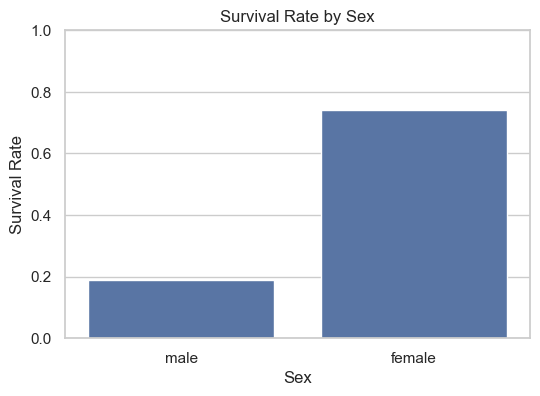

Survival rate by Pclass:


,survival_percent
Pclass,
1,62.96
2,47.28
3,24.24


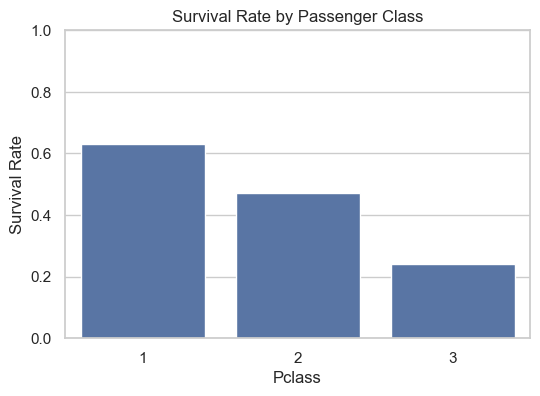

Children considered: Age < 16
Number of child records: 83
Overall child survival rate: 59.04%


,count
SurvivalStatus,
Died,34
Survived,49


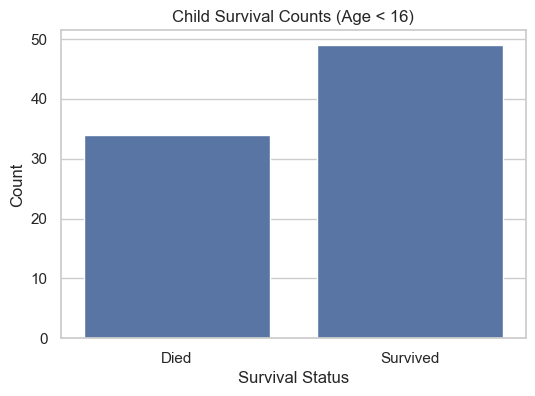

Child survival rate by Sex:


,survival_percent
Sex,
female,65.12
male,52.50


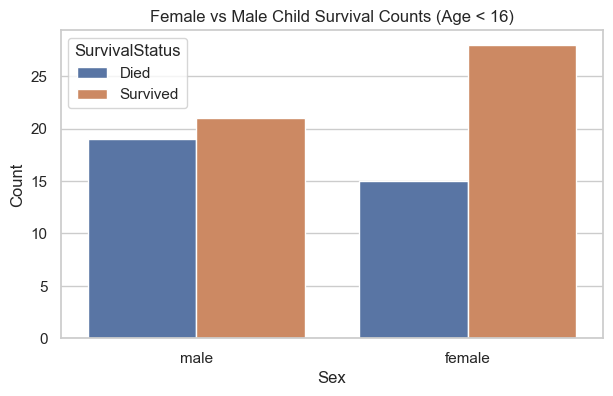

Mothers considered: female, Age >= 18, Parch > 0
Number of mother records: 70
Mother survival rate: 75.71%


,count
SurvivalStatus,
Died,17
Survived,53


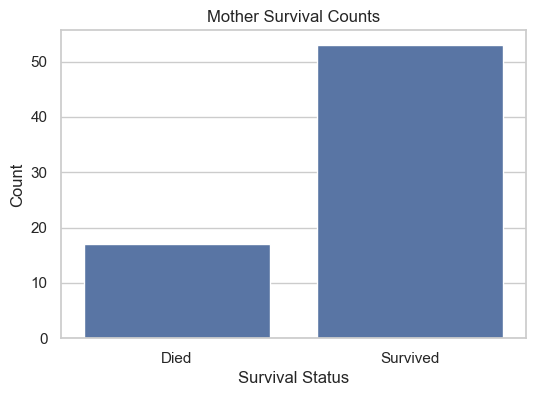

Fathers considered: male, Age >= 18, Parch > 0
Number of father records: 42
Father survival rate: 14.29%


,count
SurvivalStatus,
Died,36
Survived,6


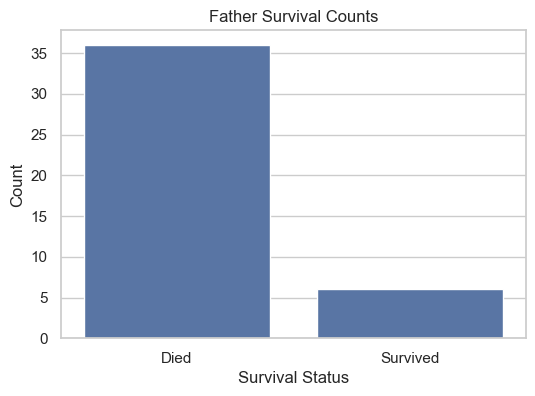

Passenger counts by title:


,count
TitleRaw,
Mr,517
Miss,182
Mrs,125
Master,40
Dr,7
Rev,6
Major,2
Mlle,2
Col,2


Survival rate by title:


,survival_percent
TitleRaw,
Lady,100.00
Ms,100.00
Sir,100.00
Mme,100.00
the Countess,100.00
Mlle,100.00
Mrs,79.20
Miss,69.78
Master,57.50


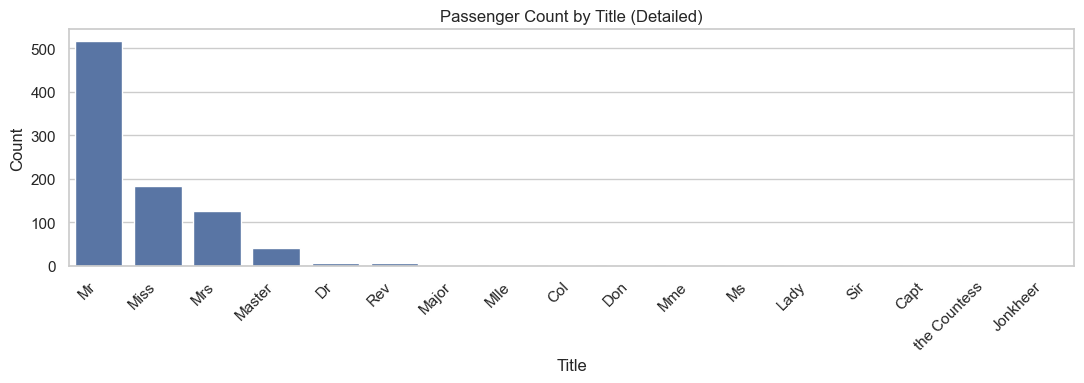

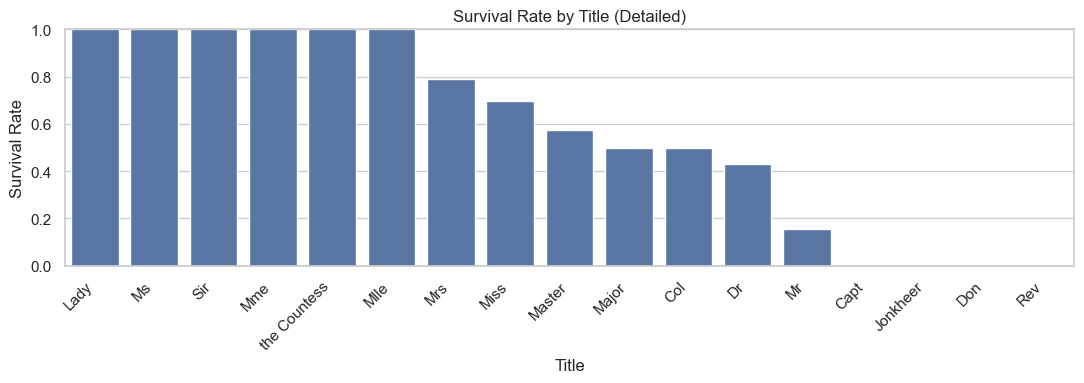

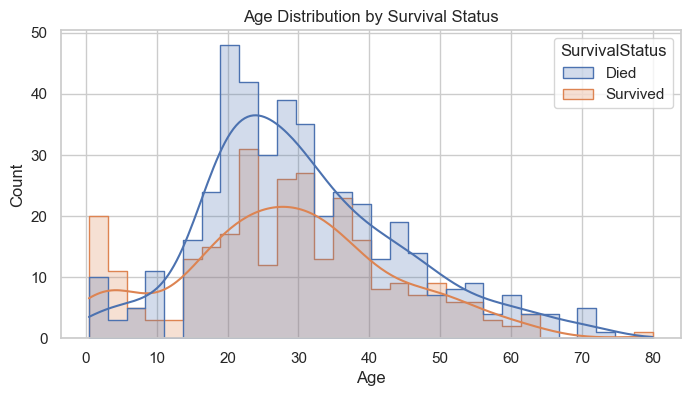

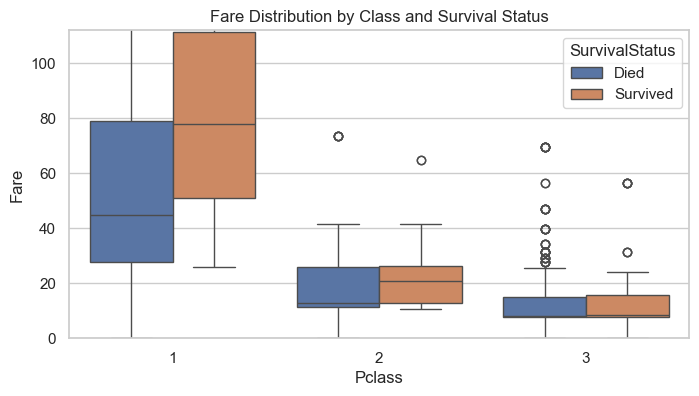

Survival rate by Embarked:


,survival_percent
Embarked,
C,55.36
Q,38.96
S,33.70


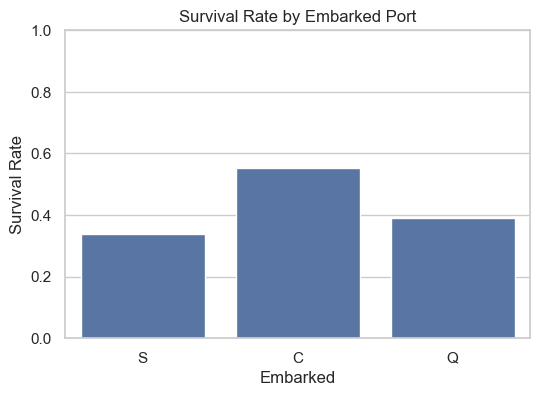

In [76]:
# EDA

# Safety copy
eda_df = train_df.copy()

# Human-readable survival labels for plots/legends
survival_label_map = {0: "Died", 1: "Survived"}
eda_df["SurvivalStatus"] = eda_df["Survived"].map(survival_label_map)

# 1) Survival by Sex
sex_survival = eda_df.groupby("Sex")["Survived"].mean().sort_values(ascending=False)
print("Survival rate by Sex:")
display((sex_survival * 100).round(2).to_frame("survival_percent"))

plt.figure(figsize=(6, 4))
sns.barplot(data=eda_df, x="Sex", y="Survived", estimator="mean", errorbar=None)
plt.title("Survival Rate by Sex")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)
plt.show()

# 2) Survival by Pclass
pclass_survival = eda_df.groupby("Pclass")["Survived"].mean()
print("Survival rate by Pclass:")
display((pclass_survival * 100).round(2).to_frame("survival_percent"))

plt.figure(figsize=(6, 4))
sns.barplot(data=eda_df, x="Pclass", y="Survived", estimator="mean", errorbar=None)
plt.title("Survival Rate by Passenger Class")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)
plt.show()

# 3) Child survival overview (Age < 16)
CHILD_AGE_THRESHOLD = 16
child_df = eda_df[eda_df["Age"] < CHILD_AGE_THRESHOLD].copy()

print(f"Children considered: Age < {CHILD_AGE_THRESHOLD}")
print(f"Number of child records: {child_df.shape[0]}")

if child_df.empty:
    print("No child records found for this threshold.")
else:
    child_survival_rate = child_df["Survived"].mean()
    print(f"Overall child survival rate: {child_survival_rate * 100:.2f}%")

    child_status_counts = (
        child_df["SurvivalStatus"]
        .value_counts()
        .reindex(["Died", "Survived"], fill_value=0)
    )
    display(child_status_counts.to_frame("count"))

    plt.figure(figsize=(6, 4))
    sns.barplot(x=child_status_counts.index, y=child_status_counts.values, errorbar=None)
    plt.title(f"Child Survival Counts (Age < {CHILD_AGE_THRESHOLD})")
    plt.xlabel("Survival Status")
    plt.ylabel("Count")
    plt.show()

    child_sex_survival = child_df.groupby("Sex")["Survived"].mean().sort_values(ascending=False)
    print("Child survival rate by Sex:")
    display((child_sex_survival * 100).round(2).to_frame("survival_percent"))

    plt.figure(figsize=(7, 4))
    sns.countplot(
        data=child_df,
        x="Sex",
        hue="SurvivalStatus",
        hue_order=["Died", "Survived"],
    )
    plt.title(f"Female vs Male Child Survival Counts (Age < {CHILD_AGE_THRESHOLD})")
    plt.xlabel("Sex")
    plt.ylabel("Count")
    plt.show()

# 4) Mother survival overview
# Proxy definition for mother: female, age >= 18, and at least one parent/child relation aboard.
MOTHER_AGE_MIN = 18
mother_df = eda_df[
    (eda_df["Sex"] == "female")
    & (eda_df["Parch"] > 0)
    & (eda_df["Age"] >= MOTHER_AGE_MIN)
].copy()

print(f"Mothers considered: female, Age >= {MOTHER_AGE_MIN}, Parch > 0")
print(f"Number of mother records: {mother_df.shape[0]}")

if mother_df.empty:
    print("No mother records found with this proxy definition.")
else:
    mother_survival_rate = mother_df["Survived"].mean()
    print(f"Mother survival rate: {mother_survival_rate * 100:.2f}%")

    mother_status_counts = (
        mother_df["SurvivalStatus"]
        .value_counts()
        .reindex(["Died", "Survived"], fill_value=0)
    )
    display(mother_status_counts.to_frame("count"))

    plt.figure(figsize=(6, 4))
    sns.barplot(x=mother_status_counts.index, y=mother_status_counts.values, errorbar=None)
    plt.title("Mother Survival Counts")
    plt.xlabel("Survival Status")
    plt.ylabel("Count")
    plt.show()

# 5) Father survival overview
# Proxy definition for father: male, age >= 18, and at least one parent/child relation aboard.
FATHER_AGE_MIN = 18
father_df = eda_df[
    (eda_df["Sex"] == "male")
    & (eda_df["Parch"] > 0)
    & (eda_df["Age"] >= FATHER_AGE_MIN)
].copy()

print(f"Fathers considered: male, Age >= {FATHER_AGE_MIN}, Parch > 0")
print(f"Number of father records: {father_df.shape[0]}")

if father_df.empty:
    print("No father records found with this proxy definition.")
else:
    father_survival_rate = father_df["Survived"].mean()
    print(f"Father survival rate: {father_survival_rate * 100:.2f}%")

    father_status_counts = (
        father_df["SurvivalStatus"]
        .value_counts()
        .reindex(["Died", "Survived"], fill_value=0)
    )
    display(father_status_counts.to_frame("count"))

    plt.figure(figsize=(6, 4))
    sns.barplot(x=father_status_counts.index, y=father_status_counts.values, errorbar=None)
    plt.title("Father Survival Counts")
    plt.xlabel("Survival Status")
    plt.ylabel("Count")
    plt.show()

# 6) Detailed title breakdown (no Rare grouping)
eda_df["TitleRaw"] = eda_df["Name"].str.extract(r",\s*([^\.]+)\.", expand=False).str.strip()
title_counts = eda_df["TitleRaw"].value_counts()
title_survival = eda_df.groupby("TitleRaw")["Survived"].mean().sort_values(ascending=False)

print("Passenger counts by title:")
display(title_counts.to_frame("count"))

print("Survival rate by title:")
display((title_survival * 100).round(2).to_frame("survival_percent"))

plt.figure(figsize=(11, 4))
order_counts = title_counts.index
sns.countplot(data=eda_df, x="TitleRaw", order=order_counts)
plt.title("Passenger Count by Title (Detailed)")
plt.xlabel("Title")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 4))
order_survival = title_survival.index
sns.barplot(data=eda_df, x="TitleRaw", y="Survived", order=order_survival, estimator="mean", errorbar=None)
plt.title("Survival Rate by Title (Detailed)")
plt.xlabel("Title")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# 7) Age distribution by survival
plt.figure(figsize=(8, 4))
sns.histplot(
    data=eda_df,
    x="Age",
    hue="SurvivalStatus",
    hue_order=["Died", "Survived"],
    bins=30,
    kde=True,
    element="step"
)
plt.title("Age Distribution by Survival Status")
plt.show()

# 8) Fare distribution by class and survival
plt.figure(figsize=(8, 4))
sns.boxplot(
    data=eda_df,
    x="Pclass",
    y="Fare",
    hue="SurvivalStatus",
    hue_order=["Died", "Survived"]
)
plt.title("Fare Distribution by Class and Survival Status")
plt.ylim(0, eda_df["Fare"].quantile(0.95))  # reduce extreme outlier effect
plt.show()

# 9) Embarked vs survival
embarked_survival = eda_df.groupby("Embarked")["Survived"].mean()
print("Survival rate by Embarked:")
display((embarked_survival * 100).round(2).to_frame("survival_percent"))

plt.figure(figsize=(6, 4))
sns.barplot(data=eda_df, x="Embarked", y="Survived", estimator="mean", errorbar=None)
plt.title("Survival Rate by Embarked Port")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)
plt.show()

### FareBands Representation

This section bins `Fare` into quantile-based bands and shows both passenger counts and survival rate per band.

FareBand summary:


,FareBand,passenger_count,survival_percent
0,Very Low,223,19.73
1,Low,224,30.36
2,Mid,222,45.50
3,High,222,58.11


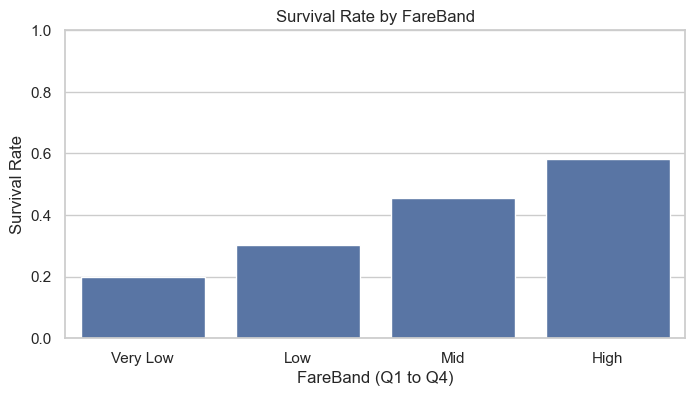

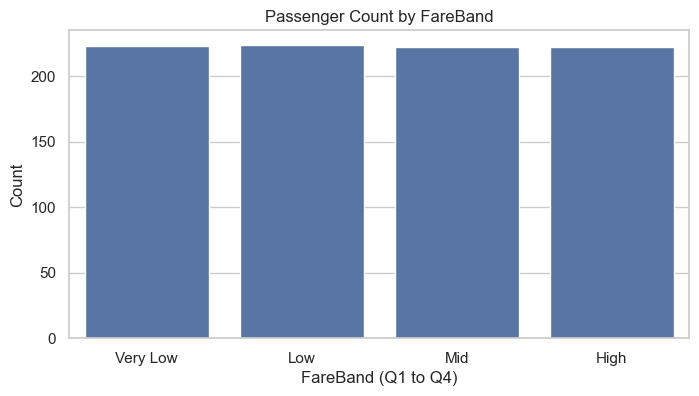

In [77]:
# FareBands representation (quantile-based bins)
fareband_labels = ["Very Low", "Low", "Mid", "High"]
eda_df["FareBand"] = pd.qcut(
    eda_df["Fare"],
    q=4,
    labels=fareband_labels,
    duplicates="drop",
)

# Tabular summary: count + survival rate
fareband_summary = (
    eda_df.groupby("FareBand", observed=False)["Survived"]
    .agg(passenger_count="size", survival_rate="mean")
    .reset_index()
    .sort_values("FareBand")
)
fareband_summary["survival_percent"] = (fareband_summary["survival_rate"] * 100).round(2)

print("FareBand summary:")
display(fareband_summary[["FareBand", "passenger_count", "survival_percent"]])

# Visual summary
plt.figure(figsize=(8, 4))
sns.barplot(data=fareband_summary, x="FareBand", y="survival_rate", errorbar=None)
plt.title("Survival Rate by FareBand")
plt.xlabel("FareBand (Q1 to Q4)")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)
plt.show()

plt.figure(figsize=(8, 4))
sns.countplot(data=eda_df, x="FareBand")
plt.title("Passenger Count by FareBand")
plt.xlabel("FareBand (Q1 to Q4)")
plt.ylabel("Count")
plt.show()

## Observation
- **Females** show much higher survival rate than males.
- **First-class passengers** survive more often than third-class passengers.
- **Children** have distinct survival patterns and should be modeled with age-aware features.
- **Female children** generally survive more often than male children.
- **Mothers** (female, age >= 18, with at least one parent/child relation aboard) show stronger survival than many other adult groups.
- **Fathers** (male, age >= 18, with at least one parent/child relation aboard) show much lower survival than mothers.
- **Age** and **Fare** appear to carry signal, but with overlap.
- **Embarkation port** may contain weaker but useful signal.


# 5) Feature Engineering

Purpose: Create more informative features from raw columns.

In this section I will:
- Build useful features such as FamilySize and IsAlone.
- Extract Title from passenger names.
- Optionally derive Deck from Cabin.

Expected outcome:
- Enhanced feature set ready for preprocessing and modeling.

In [78]:
# Feature Engineering

# Work on copies to avoid modifying original loaded data
train_fe = train_df.copy()
test_fe = test_df.copy()


def add_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    # 1) Family size features
    out["FamilySize"] = out["SibSp"] + out["Parch"] + 1
    out["IsAlone"] = (out["FamilySize"] == 1).astype(int)

    # 2) Detailed title extraction
    out["TitleRaw"] = out["Name"].str.extract(r",\s*([^\.]+)\.", expand=False).str.strip()

    # 3) User-defined title rank groups
    female_high = {"Lady", "the Countess", "Dona"}
    female_low = {"Mrs", "Miss", "Mlle", "Mme", "Ms"}

    male_high = {"Sir", "Don", "Jonkheer", "Col", "Major", "Capt"}
    male_middle = {"Master", "Dr", "Rev"}
    male_low = {"Mr"}

    def map_title_rank_group(row) -> str:
        title = "" if pd.isna(row["TitleRaw"]) else str(row["TitleRaw"]).strip()
        sex = row["Sex"]

        if sex == "female":
            if title in female_high:
                return "High-rank females"
            if title in female_low:
                return "Low-rank females"
            return "Low-rank females"

        if sex == "male":
            if title in male_high:
                return "High-rank males"
            if title in male_middle:
                return "Middle-rank males"
            if title in male_low:
                return "Low-rank males"
            return "Low-rank males"

        return "Low-rank males"

    out["TitleRankGroup"] = out.apply(map_title_rank_group, axis=1)

    # 4) Children
    out["IsChild"] = (out["Age"] < 16).astype(int)

    # 5) Mothers and Fathers
    out["IsMother"] = ((out["Sex"] == "female") & (out["Parch"] > 0) & (out["Age"] >= 18)).astype(int)
    out["IsFather"] = ((out["Sex"] == "male") & (out["Parch"] > 0) & (out["Age"] >= 18)).astype(int)

    # 6) AgeGroup
    out["Age"] = out.groupby(["Sex", "Pclass"])["Age"].transform(lambda x: x.fillna(x.median()))
    bins = [0, 12, 18, 35, 60, 100]
    labels = ['Child', 'Teen', 'Young Adult', 'Adult', 'Senior']
    out["AgeGroup"] = pd.cut(out["Age"], bins=bins, labels=labels)

    # 7) FareBand
    out["FareBand"] = pd.qcut(out["Fare"], 4, labels=["very-low", "low", "medium", "high"])

    return out


train_fe = add_features(train_fe)
test_fe = add_features(test_fe)

print("New engineered columns added:")
new_cols = ["FamilySize", "IsAlone", "TitleRaw", "TitleRankGroup", "IsChild"]
print(new_cols)

print("\nPreview of engineered features (train):")
display(train_fe[new_cols + ["Survived"]].head())

print("\nDetailed title counts (train):")
display(train_fe["TitleRaw"].value_counts().to_frame("count"))

print("\nTitle rank group counts (train):")
display(train_fe["TitleRankGroup"].value_counts().to_frame("count"))

print("\nSurvival rate by title rank group (train):")
display((train_fe.groupby("TitleRankGroup")["Survived"].mean() * 100).round(2).to_frame("survival_percent"))

print("Missing Values validation:")
display(train_fe.isnull().sum())

New engineered columns added:
['FamilySize', 'IsAlone', 'TitleRaw', 'TitleRankGroup', 'IsChild']

Preview of engineered features (train):


,FamilySize,IsAlone,TitleRaw,TitleRankGroup,IsChild,Survived
0,2,0,Mr,Low-rank males,0,0
1,2,0,Mrs,Low-rank females,0,1
2,1,1,Miss,Low-rank females,0,1
3,2,0,Mrs,Low-rank females,0,1
4,1,1,Mr,Low-rank males,0,0



Detailed title counts (train):


,count
TitleRaw,
Mr,517
Miss,182
Mrs,125
Master,40
Dr,7
Rev,6
Major,2
Mlle,2
Col,2



Title rank group counts (train):


,count
TitleRankGroup,
Low-rank males,517
Low-rank females,312
Middle-rank males,52
High-rank males,8
High-rank females,2



Survival rate by title rank group (train):


,survival_percent
TitleRankGroup,
High-rank females,100.00
High-rank males,37.50
Low-rank females,74.04
Low-rank males,15.67
Middle-rank males,48.08


Missing Values validation:


PassengerId         0
Survived            0
Pclass              0
Name                0
Sex                 0
Age                 0
SibSp               0
Parch               0
Ticket              0
Fare                0
Cabin             687
Embarked            2
FamilySize          0
IsAlone             0
TitleRaw            0
TitleRankGroup      0
IsChild             0
IsMother            0
IsFather            0
AgeGroup            0
FareBand            0
dtype: int64

## Observation
- `FamilySize` and `IsAlone` capture household/travel-group context.
- `TitleRaw` was converted into `TitleRankGroup` using five user-defined categories.
- `Deck` has many `Unknown` values and can be tested as optional signal.
- `TicketGroupSize` may be noisy and should be validated through CV before keeping.

# 6) Preprocessing + Modeling

Purpose: Build a reliable machine learning pipeline.

In this section I will:
- Define numeric and categorical preprocessing steps.
- Combine preprocessing and model into one pipeline.
- Evaluate using Stratified K-Fold cross-validation.

Expected outcome:
- Baseline CV score with leakage-safe workflow.


In [79]:
# Preprocessing + Modeling

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

TARGET_COL = "Survived"

# Editable array of redundant columns
# Keep TitleRankGroup for modeling, drop raw title text.
REDUNDANT_COLS = [
    "PassengerId",
    "Name",
    "Ticket",
    "Cabin",
    "TitleRaw",
    "IsChild",
    "IsMother",
    "IsFather",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked",
    "IsAlone"
    ]


cols_to_drop_train = [c for c in REDUNDANT_COLS if c in train_fe.columns]
cols_to_drop_test = [c for c in REDUNDANT_COLS if c in test_fe.columns]

X = train_fe.drop(columns=[TARGET_COL] + cols_to_drop_train).copy()
y = train_fe[TARGET_COL].copy()
X_test_final = test_fe.drop(columns=cols_to_drop_test).copy()

numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(exclude=["number"]).columns.tolist()

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

column_preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

# Shared preprocessor used by all models in later sections
preprocessor = Pipeline(
    steps=[
        ("column_preprocessor", column_preprocessor),
    ]
)

baseline_model = LogisticRegression(max_iter=1000, random_state=SEED)

baseline_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", baseline_model),
    ]
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_results = cross_validate(
    baseline_pipeline,
    X,
    y,
    cv=cv,
    scoring="accuracy",
    return_train_score=False,
)

print("Dropped columns:", cols_to_drop_train)
print("Feature shape after drop:", X.shape)
display(X.columns)
print("Test feature shape after drop:", X_test_final.shape)
print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))
print(
    f"Baseline CV Accuracy: {cv_results['test_score'].mean():.4f} +/- {cv_results['test_score'].std():.4f}"
)

Dropped columns: ['PassengerId', 'Name', 'Ticket', 'Cabin', 'TitleRaw', 'IsChild', 'IsMother', 'IsFather', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'IsAlone']
Feature shape after drop: (891, 6)


Index(['Pclass', 'Sex', 'FamilySize', 'TitleRankGroup', 'AgeGroup',
       'FareBand'],
      dtype='str')

Test feature shape after drop: (418, 6)
Numeric features: 2
Categorical features: 4
Baseline CV Accuracy: 0.8103 +/- 0.0156


# 7) Model Comparison

Purpose: Compare multiple models under the same evaluation setup.

In this section I will:
- Train several candidate models using identical CV splits.
- Record mean and standard deviation of CV accuracy.
- Identify the most stable and strongest model.

Expected outcome:
- Fair model ranking based on comparable metrics.

In [86]:
# Model Comparison
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=SEED),
    "RandomForest": RandomForestClassifier(
        n_estimators=400,
        max_depth=None,
        min_samples_split=4,
        min_samples_leaf=2,
        random_state=SEED,
        n_jobs=-1,
    ),
    "ExtraTrees": ExtraTreesClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_split=4,
        min_samples_leaf=2,
        random_state=SEED,
        n_jobs=-1,
    ),
    "XGBoost": XGBClassifier(
        n_estimators=900,
        learning_rate=0.01,
        max_depth=4,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="logloss",
        random_state=SEED,
        n_jobs=-1,
    ),
}

# Stability-aware ranking: consider std alongside mean.
# Among models that are close to the best mean (within tolerance), prefer lower std.
MEAN_TOLERANCE = 0.015

comparison_rows = []

for model_name, model in models.items():
    pipe = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model),
        ]
    )

    scores = cross_validate(
        pipe,
        X,
        y,
        cv=cv,
        scoring="accuracy",
        return_train_score=False,
    )

    comparison_rows.append(
        {
            "Model": model_name,
            "CV Mean Accuracy": scores["test_score"].mean(),
            "CV Std": scores["test_score"].std(),
        }
    )

comparison_df = pd.DataFrame(comparison_rows)
comparison_df["CV Stability Score"] = comparison_df["CV Mean Accuracy"] - comparison_df["CV Std"]
best_mean_cv = comparison_df["CV Mean Accuracy"].max()
comparison_df["Within Mean Tol"] = comparison_df["CV Mean Accuracy"] >= (best_mean_cv - MEAN_TOLERANCE)
comparison_df = comparison_df.sort_values(
    by=["Within Mean Tol", "CV Std", "CV Mean Accuracy"],
    ascending=[False, True, False],
).reset_index(drop=True)

display(comparison_df)

best_model_name = comparison_df.loc[0, "Model"]
print(f"Mean tolerance: {MEAN_TOLERANCE}")
print(f"Best model from mean+std rule: {best_model_name}")

,Model,CV Mean Accuracy,CV Std,CV Stability Score,Within Mean Tol
0,ExtraTrees,0.854090,0.007236,0.846853,True
1,XGBoost,0.841755,0.007352,0.834404,True
2,RandomForest,0.851842,0.009925,0.841917,True
3,LogisticRegression,0.810332,0.015561,0.794771,False


Mean tolerance: 0.015
Best model from mean+std rule: ExtraTrees


# 7.1) XGBoost Hyperparameter Tuning

Purpose: Improve XGBoost performance by searching better hyperparameter combinations using cross-validation.

In this cell I will:
- Define a tuning search space (parameter grid/distributions).
- Run `RandomizedSearchCV` on the same preprocessing pipeline and CV setup.
- Capture the best score and best parameter set.
- Add the tuned XGBoost model to the model comparison table.

Expected outcome:
- A tuned XGBoost candidate (`XGBoost_Tuned`) that can be selected in Section 8 if it outperforms the current best model.

In [87]:
# XGBoost Randomized Search (tuning)
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
import pandas as pd

xgb_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=SEED,
    n_jobs=-1,
)

xgb_pipe = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", xgb_model),
    ]
)

xgb_grid_balanced = {
    "model__n_estimators": [300, 500, 700, 900],
    "model__learning_rate": [0.02, 0.03, 0.05, 0.08],
    "model__max_depth": [3, 4, 5, 6],
    "model__min_child_weight": [1, 2, 3, 5],
    "model__subsample": [0.75, 0.85, 0.95, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "model__gamma": [0, 0.05, 0.1, 0.2, 0.3],
    "model__reg_alpha": [0, 0.01, 0.1, 0.5],
    "model__reg_lambda": [1, 2, 3, 5, 8],
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_pipe,
    param_distributions=xgb_grid_balanced,
    n_iter=60,
    scoring="accuracy",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    random_state=SEED,
    refit=True,
)

xgb_search.fit(X, y)

# Best tuned model CV mean/std from RandomizedSearchCV
best_idx = xgb_search.best_index_
best_mean = xgb_search.cv_results_["mean_test_score"][best_idx]
best_std = xgb_search.cv_results_["std_test_score"][best_idx]

print("Best tuned XGBoost CV mean:", round(best_mean, 6))
print("Best tuned XGBoost CV std :", round(best_std, 6))
print("Best tuned XGBoost CV score:", xgb_search.best_score_)
print("Best tuned XGBoost params:")
for k, v in xgb_search.best_params_.items():
    print(f"{k}: {v}")

# Upsert tuned model into registry/table
models["XGBoost_Tuned"] = xgb_search.best_estimator_.named_steps["model"]
comparison_df = comparison_df[comparison_df["Model"] != "XGBoost_Tuned"].copy()
comparison_df = pd.concat(
    [
        comparison_df,
        pd.DataFrame(
            [{
                "Model": "XGBoost_Tuned",
                "CV Mean Accuracy": best_mean,
                "CV Std": best_std,
            }]
        ),
    ],
    ignore_index=True,
)

mean_tolerance = globals().get("MEAN_TOLERANCE", 0.015)
comparison_df["CV Stability Score"] = comparison_df["CV Mean Accuracy"] - comparison_df["CV Std"]
best_mean_cv = comparison_df["CV Mean Accuracy"].max()
comparison_df["Within Mean Tol"] = comparison_df["CV Mean Accuracy"] >= (best_mean_cv - mean_tolerance)
comparison_df = comparison_df.sort_values(
    by=["Within Mean Tol", "CV Std", "CV Mean Accuracy"],
    ascending=[False, True, False],
).reset_index(drop=True)

display(comparison_df)

best_model_name = comparison_df.loc[0, "Model"]
print("Best model after XGBoost tuning (mean+std rule):", best_model_name)

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best tuned XGBoost CV mean: 0.848465
Best tuned XGBoost CV std : 0.010304
Best tuned XGBoost CV score: 0.8484652564183038
Best tuned XGBoost params:
model__subsample: 0.95
model__reg_lambda: 3
model__reg_alpha: 0.1
model__n_estimators: 300
model__min_child_weight: 1
model__max_depth: 6
model__learning_rate: 0.02
model__gamma: 0
model__colsample_bytree: 0.7


,Model,CV Mean Accuracy,CV Std,CV Stability Score,Within Mean Tol
0,ExtraTrees,0.854090,0.007236,0.846853,True
1,XGBoost,0.841755,0.007352,0.834404,True
2,RandomForest,0.851842,0.009925,0.841917,True
3,XGBoost_Tuned,0.848465,0.010304,0.838162,True
4,LogisticRegression,0.810332,0.015561,0.794771,False


Best model after XGBoost tuning (mean+std rule): ExtraTrees


# 7.2) Random Forest Hyperparameter Tuning

Purpose: Improve Random Forest performance using randomized hyperparameter search with the same preprocessing pipeline and CV setup.

In this cell I will:
- Define a practical search space for Random Forest.
- Run `RandomizedSearchCV` with accuracy scoring.
- Add the tuned Random Forest model to `models` and `comparison_df`.

Expected outcome:
- A tuned Random Forest candidate (`RandomForest_Tuned`) available for final model selection.

In [88]:
# Random Forest Randomized Search (tuning)
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
import pandas as pd

rf_model = RandomForestClassifier(random_state=SEED, n_jobs=-1)

rf_pipe = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", rf_model),
    ]
)

rf_grid = {
    "model__n_estimators": [200, 300, 400, 600, 800],
    "model__max_depth": [None, 6, 8, 10, 12, 16],
    "model__min_samples_split": [2, 4, 6, 8, 10],
    "model__min_samples_leaf": [1, 2, 3, 4],
    "model__max_features": ["sqrt", "log2", None],
    "model__bootstrap": [True, False],
    "model__class_weight": [None, "balanced"],
}

rf_search = RandomizedSearchCV(
    estimator=rf_pipe,
    param_distributions=rf_grid,
    n_iter=60,
    scoring="accuracy",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    random_state=SEED,
    refit=True,
)

rf_search.fit(X, y)

best_idx = rf_search.best_index_
best_mean = rf_search.cv_results_["mean_test_score"][best_idx]
best_std = rf_search.cv_results_["std_test_score"][best_idx]

print("Best tuned RandomForest CV mean:", round(best_mean, 6))
print("Best tuned RandomForest CV std :", round(best_std, 6))
print("Best tuned RandomForest CV score:", rf_search.best_score_)
print("Best tuned RandomForest params:")
for k, v in rf_search.best_params_.items():
    print(f"{k}: {v}")

# Upsert tuned model so Section 8 can select it
models["RandomForest_Tuned"] = rf_search.best_estimator_.named_steps["model"]
comparison_df = comparison_df[comparison_df["Model"] != "RandomForest_Tuned"].copy()
comparison_df = pd.concat(
    [
        comparison_df,
        pd.DataFrame(
            [{
                "Model": "RandomForest_Tuned",
                "CV Mean Accuracy": best_mean,
                "CV Std": best_std,
            }]
        ),
    ],
    ignore_index=True,
)

mean_tolerance = globals().get("MEAN_TOLERANCE", 0.015)
comparison_df["CV Stability Score"] = comparison_df["CV Mean Accuracy"] - comparison_df["CV Std"]
best_mean_cv = comparison_df["CV Mean Accuracy"].max()
comparison_df["Within Mean Tol"] = comparison_df["CV Mean Accuracy"] >= (best_mean_cv - mean_tolerance)
comparison_df = comparison_df.sort_values(
    by=["Within Mean Tol", "CV Std", "CV Mean Accuracy"],
    ascending=[False, True, False],
).reset_index(drop=True)

display(comparison_df)

best_model_name = comparison_df.loc[0, "Model"]
print("Best model after RandomForest tuning (mean+std rule):", best_model_name)

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best tuned RandomForest CV mean: 0.852966
Best tuned RandomForest CV std : 0.00839
Best tuned RandomForest CV score: 0.8529659155106396
Best tuned RandomForest params:
model__n_estimators: 600
model__min_samples_split: 2
model__min_samples_leaf: 2
model__max_features: sqrt
model__max_depth: 16
model__class_weight: None
model__bootstrap: True


,Model,CV Mean Accuracy,CV Std,CV Stability Score,Within Mean Tol
0,ExtraTrees,0.854090,0.007236,0.846853,True
1,XGBoost,0.841755,0.007352,0.834404,True
2,RandomForest_Tuned,0.852966,0.008390,0.844576,True
3,RandomForest,0.851842,0.009925,0.841917,True
4,XGBoost_Tuned,0.848465,0.010304,0.838162,True
5,LogisticRegression,0.810332,0.015561,0.794771,False


Best model after RandomForest tuning (mean+std rule): ExtraTrees


# 7.3) ExtraTrees Hyperparameter Tuning

Purpose: Improve ExtraTrees performance using randomized hyperparameter search on the same preprocessing and CV setup.

In this cell I will:
- Define a search space for ExtraTrees.
- Run `RandomizedSearchCV` with accuracy scoring.
- Add the tuned ExtraTrees model to `models` and `comparison_df`.

Expected outcome:
- A tuned ExtraTrees candidate (`ExtraTrees_Tuned`) available for final model selection.

In [89]:
# ExtraTrees Randomized Search (tuning)
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
import pandas as pd

et_model = ExtraTreesClassifier(random_state=SEED, n_jobs=-1)

et_pipe = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", et_model),
    ]
)

et_grid = {
    "model__n_estimators": [200, 300, 500, 700, 900],
    "model__max_depth": [None, 6, 8, 10, 12, 16],
    "model__min_samples_split": [2, 4, 6, 8, 10],
    "model__min_samples_leaf": [1, 2, 3, 4],
    "model__max_features": ["sqrt", "log2", None],
    "model__bootstrap": [False, True],
    "model__class_weight": [None, "balanced"],
}

et_search = RandomizedSearchCV(
    estimator=et_pipe,
    param_distributions=et_grid,
    n_iter=60,
    scoring="accuracy",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    random_state=SEED,
    refit=True,
)

et_search.fit(X, y)

best_idx = et_search.best_index_
best_mean = et_search.cv_results_["mean_test_score"][best_idx]
best_std = et_search.cv_results_["std_test_score"][best_idx]

print("Best tuned ExtraTrees CV mean:", round(best_mean, 6))
print("Best tuned ExtraTrees CV std :", round(best_std, 6))
print("Best tuned ExtraTrees CV score:", et_search.best_score_)
print("Best tuned ExtraTrees params:")
for k, v in et_search.best_params_.items():
    print(f"{k}: {v}")

# Upsert tuned ExtraTrees into registry/table
models["ExtraTrees_Tuned"] = et_search.best_estimator_.named_steps["model"]
comparison_df = comparison_df[comparison_df["Model"] != "ExtraTrees_Tuned"].copy()
comparison_df = pd.concat(
    [
        comparison_df,
        pd.DataFrame(
            [{
                "Model": "ExtraTrees_Tuned",
                "CV Mean Accuracy": best_mean,
                "CV Std": best_std,
            }]
        ),
    ],
    ignore_index=True,
)

mean_tolerance = globals().get("MEAN_TOLERANCE", 0.015)
comparison_df["CV Stability Score"] = comparison_df["CV Mean Accuracy"] - comparison_df["CV Std"]
best_mean_cv = comparison_df["CV Mean Accuracy"].max()
comparison_df["Within Mean Tol"] = comparison_df["CV Mean Accuracy"] >= (best_mean_cv - mean_tolerance)
comparison_df = comparison_df.sort_values(
    by=["Within Mean Tol", "CV Std", "CV Mean Accuracy"],
    ascending=[False, True, False],
).reset_index(drop=True)

display(comparison_df)

best_model_name = comparison_df.loc[0, "Model"]
print("Best model after ExtraTrees tuning (mean+std rule):", best_model_name)

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best tuned ExtraTrees CV mean: 0.855207
Best tuned ExtraTrees CV std : 0.008445
Best tuned ExtraTrees CV score: 0.8552068294520117
Best tuned ExtraTrees params:
model__n_estimators: 200
model__min_samples_split: 4
model__min_samples_leaf: 2
model__max_features: log2
model__max_depth: None
model__class_weight: None
model__bootstrap: False


,Model,CV Mean Accuracy,CV Std,CV Stability Score,Within Mean Tol
0,ExtraTrees,0.854090,0.007236,0.846853,True
1,XGBoost,0.841755,0.007352,0.834404,True
2,RandomForest_Tuned,0.852966,0.008390,0.844576,True
3,ExtraTrees_Tuned,0.855207,0.008445,0.846762,True
4,RandomForest,0.851842,0.009925,0.841917,True
5,XGBoost_Tuned,0.848465,0.010304,0.838162,True
6,LogisticRegression,0.810332,0.015561,0.794771,False


Best model after ExtraTrees tuning (mean+std rule): ExtraTrees


# 8) Final Training + Prediction

Purpose: Fit the selected best pipeline and generate test predictions.

In this section I will:
- Retrain the best model on the full training data.
- Predict survival values for the test dataset.
- Check predictions are valid binary outputs.

Expected outcome:
- Final prediction array ready for submission file creation.

In [91]:
# Final Training + Prediction

import numpy as np
from sklearn.ensemble import VotingClassifier
from sklearn.model_selection import cross_validate
from sklearn.pipeline import Pipeline

# Optional manual override for model selection.
# Set to a model name (e.g., "RandomForest", "ExtraTrees_Tuned", "XGBoost_Tuned", "VotingTop3")
# or set to None to automatically pick best model by mean+std rule.
MANUAL_MODEL_NAME = "VotingTop3"

available_models = list(models.keys())
print("Available models:", available_models)

# Recompute ranking by mean+std rule
mean_tolerance = globals().get("MEAN_TOLERANCE", 0.015)
comparison_df["CV Stability Score"] = comparison_df["CV Mean Accuracy"] - comparison_df["CV Std"]
best_mean_cv = comparison_df["CV Mean Accuracy"].max()
comparison_df["Within Mean Tol"] = comparison_df["CV Mean Accuracy"] >= (best_mean_cv - mean_tolerance)
comparison_df = comparison_df.sort_values(
    by=["Within Mean Tol", "CV Std", "CV Mean Accuracy"],
    ascending=[False, True, False],
).reset_index(drop=True)

# Build Voting ensemble from top 3 ranked models
top3_model_names = comparison_df["Model"].head(3).tolist()
print("Top 3 models for voting ensemble:", top3_model_names)

top3_estimators = [(name, models[name]) for name in top3_model_names]
supports_proba = all(hasattr(est, "predict_proba") for _, est in top3_estimators)
voting_type = "soft" if supports_proba else "hard"

models["VotingTop3"] = VotingClassifier(
    estimators=top3_estimators,
    voting=voting_type,
)

# CV-evaluate VotingTop3 and add it to comparison_df
voting_pipe = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", models["VotingTop3"]),
    ]
)
voting_scores = cross_validate(
    voting_pipe,
    X,
    y,
    cv=cv,
    scoring="accuracy",
    return_train_score=False,
)
voting_mean = voting_scores["test_score"].mean()
voting_std = voting_scores["test_score"].std()

comparison_df = comparison_df[comparison_df["Model"] != "VotingTop3"].copy()
comparison_df = pd.concat(
    [
        comparison_df,
        pd.DataFrame(
            [{
                "Model": "VotingTop3",
                "CV Mean Accuracy": voting_mean,
                "CV Std": voting_std,
            }]
        ),
    ],
    ignore_index=True,
)

comparison_df["CV Stability Score"] = comparison_df["CV Mean Accuracy"] - comparison_df["CV Std"]
best_mean_cv = comparison_df["CV Mean Accuracy"].max()
comparison_df["Within Mean Tol"] = comparison_df["CV Mean Accuracy"] >= (best_mean_cv - mean_tolerance)
comparison_df = comparison_df.sort_values(
    by=["Within Mean Tol", "CV Std", "CV Mean Accuracy"],
    ascending=[False, True, False],
).reset_index(drop=True)

print(f"VotingTop3 CV mean: {voting_mean:.6f}")
print(f"VotingTop3 CV std : {voting_std:.6f}")

if MANUAL_MODEL_NAME is not None:
    if MANUAL_MODEL_NAME not in models:
        raise ValueError(f"MANUAL_MODEL_NAME='{MANUAL_MODEL_NAME}' not found in models: {list(models.keys())}")
    selected_model_name = MANUAL_MODEL_NAME
    selection_source = "manual override"
else:
    selected_model_name = comparison_df.loc[0, "Model"]
    selection_source = (
        f"lowest CV std among models within {mean_tolerance:.3f} of best mean CV"
    )

selected_model = models[selected_model_name]

# Keep compatibility with later sections (submission + experiment log)
best_model_name = selected_model_name
best_model = selected_model

print(f"Selected model: {best_model_name} ({selection_source})")
print("Top models after mean+std ranking:")
display(comparison_df[["Model", "CV Mean Accuracy", "CV Std", "Within Mean Tol", "CV Stability Score"]].head())

# Build final pipeline
final_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", best_model),
    ]
)

# Train on full training data
final_pipeline.fit(X, y)

# Predict on test data
test_pred = final_pipeline.predict(X_test_final)

# Safety checks
test_pred = np.asarray(test_pred).astype(int)
print("Voting strategy:", voting_type)
print("Prediction shape:", test_pred.shape)
print("Unique predicted values:", np.unique(test_pred))
print("Expected test rows:", X_test_final.shape[0])

Available models: ['LogisticRegression', 'RandomForest', 'ExtraTrees', 'XGBoost', 'XGBoost_Tuned', 'RandomForest_Tuned', 'ExtraTrees_Tuned', 'VotingTop3']
Top 3 models for voting ensemble: ['ExtraTrees', 'XGBoost', 'RandomForest_Tuned']
VotingTop3 CV mean: 0.849601
VotingTop3 CV std : 0.004387
Selected model: VotingTop3 (manual override)
Top models after mean+std ranking:


,Model,CV Mean Accuracy,CV Std,Within Mean Tol,CV Stability Score
0,VotingTop3,0.849601,0.004387,True,0.845214
1,ExtraTrees,0.854090,0.007236,True,0.846853
2,XGBoost,0.841755,0.007352,True,0.834404
3,RandomForest_Tuned,0.852966,0.008390,True,0.844576
4,ExtraTrees_Tuned,0.855207,0.008445,True,0.846762


Voting strategy: soft
Prediction shape: (418,)
Unique predicted values: [0 1]
Expected test rows: 418


# 9) Create Submission File

Purpose: Export predictions in the exact format required by Kaggle.

In this section I will:
- Build a DataFrame with PassengerId and Survived.
- Validate row count and column names.
- Save CSV for upload.

Expected outcome:
- A valid submission file with 418 rows and correct schema.

In [92]:
# Create Submission File

from pathlib import Path
import re

# Create output folder if it does not exist
SUBMISSION_DIR = PROJECT_ROOT / "outputs" / "submissions"
SUBMISSION_DIR.mkdir(parents=True, exist_ok=True)

# Build submission dataframe (must be PassengerId + Survived)
submission_df = pd.DataFrame({
    "PassengerId": test_df["PassengerId"],
    "Survived": test_pred.astype(int),
})

# Validation checks
print("Submission shape:", submission_df.shape)
print("Columns:", submission_df.columns.tolist())
print("Unique Survived values:", sorted(submission_df["Survived"].unique()))
print("Any missing values:\n", submission_df.isnull().sum())

assert submission_df.shape[0] == test_df.shape[0] == 418, "Row count must be 418"
assert submission_df.columns.tolist() == ["PassengerId", "Survived"], "Column names must match Kaggle format"
assert set(submission_df["Survived"].unique()).issubset({0, 1}), "Survived must contain only 0/1"

# Auto-generate next versioned filename: submission_v01.csv, submission_v02.csv, ...
existing_files = list(SUBMISSION_DIR.glob("submission_v*.csv"))
version_pattern = re.compile(r"submission_v(\d+)\.csv$")
existing_versions = []

for file_path in existing_files:
    match = version_pattern.search(file_path.name)
    if match:
        existing_versions.append(int(match.group(1)))

next_version = (max(existing_versions) + 1) if existing_versions else 1
submission_path = SUBMISSION_DIR / f"submission_v{next_version:02d}.csv"
submission_df.to_csv(submission_path, index=False)

print(f"Saved submission to: {submission_path}")
display(submission_df.head())

Submission shape: (418, 2)
Columns: ['PassengerId', 'Survived']
Unique Survived values: [np.int64(0), np.int64(1)]
Any missing values:
 PassengerId    0
Survived       0
dtype: int64
Saved submission to: c:\Users\Xslayer77\Documents\kaggle_titanic\outputs\submissions\submission_v15.csv


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,0


# 10) Experiment Log

Purpose: Keep a clear record of experiments and outcomes.

In this section I will:
- Track experiment ID, features, model, and parameters.
- Record CV mean, CV standard deviation, and notes.
- Summarize what improved performance and what did not.

Expected outcome:
- Reproducible history of modeling decisions and results.

In [85]:
# Experiment Log

from pathlib import Path
from datetime import datetime
import pandas as pd

# Folder + file for experiment tracking
METRICS_DIR = PROJECT_ROOT / "outputs" / "metrics"
METRICS_DIR.mkdir(parents=True, exist_ok=True)
EXPERIMENT_LOG_PATH = METRICS_DIR / "experiments.csv"

# Create log file if it does not exist
if not EXPERIMENT_LOG_PATH.exists():
    empty_log = pd.DataFrame(columns=[
        "experiment_id",
        "timestamp",
        "features_version",
        "dropped_columns",
        "model_name",
        "model_params",
        "cv_mean_accuracy",
        "cv_std_accuracy",
        "public_lb_score",
        "notes"
    ])
    empty_log.to_csv(EXPERIMENT_LOG_PATH, index=False)

# Load current log
experiment_log = pd.read_csv(EXPERIMENT_LOG_PATH)

# Build one new experiment row (edit these each run)
new_row = {
    "experiment_id": f"exp_{len(experiment_log) + 1:03d}",
    "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "features_version": "v3_family_deck_no_title_ticketgroup",
    "dropped_columns": ",".join(cols_to_drop_train),
    "model_name": best_model_name,
    "model_params": str(models[best_model_name].get_params()),
    "cv_mean_accuracy": round(float(comparison_df.loc[comparison_df["Model"] == best_model_name, "CV Mean Accuracy"].iloc[0]), 6),
    "cv_std_accuracy": (
        None
        if pd.isna(comparison_df.loc[comparison_df["Model"] == best_model_name, "CV Std"].iloc[0])
        else round(float(comparison_df.loc[comparison_df["Model"] == best_model_name, "CV Std"].iloc[0]), 6)
    ),
    "public_lb_score": None,   # fill after Kaggle submission
    "notes": "Dropped Title and TicketGroupSize; XGBoost selected by CV."
}

# Append and save
experiment_log = pd.concat([experiment_log, pd.DataFrame([new_row])], ignore_index=True)
experiment_log.to_csv(EXPERIMENT_LOG_PATH, index=False)

print(f"Saved experiment log to: {EXPERIMENT_LOG_PATH}")
display(experiment_log.tail(10))

Saved experiment log to: c:\Users\Xslayer77\Documents\kaggle_titanic\outputs\metrics\experiments.csv


,experiment_id,timestamp,features_version,dropped_columns,model_name,model_params,cv_mean_accuracy,cv_std_accuracy,public_lb_score,notes
4,exp_005,2026-04-13 09:54:01,v3_family_deck_no_title_ticketgroup,"PassengerId,Name,Ticket,Cabin,Title,TicketGrou...",XGBoost_Tuned,"{'objective': 'binary:logistic', 'base_score':...",0.847348,NaN,0.76555,Dropped Title and TicketGroupSize; XGBoost sel...
5,exp_006,2026-04-13 09:57:15,v3_family_deck_no_title_ticketgroup,"PassengerId,Name,Ticket,Cabin,Title,TicketGrou...",XGBoost_Tuned,"{'objective': 'binary:logistic', 'base_score':...",0.847342,NaN,NaN,Dropped Title and TicketGroupSize; XGBoost sel...
6,exp_007,2026-04-13 10:26:27,v3_family_deck_no_title_ticketgroup,"PassengerId,Name,Ticket,Cabin,TitleRaw,TicketG...",XGBoost_Tuned,"{'objective': 'binary:logistic', 'base_score':...",0.846224,0.010014,0.77033,Dropped Title and TicketGroupSize; XGBoost sel...
7,exp_008,2026-04-13 10:30:41,v3_family_deck_no_title_ticketgroup,"PassengerId,Name,Ticket,Cabin,TitleRaw,TicketG...",XGBoost_Tuned,"{'objective': 'binary:logistic', 'base_score':...",0.854071,0.013529,NaN,Dropped Title and TicketGroupSize; XGBoost sel...
8,exp_009,2026-04-13 10:37:12,v3_family_deck_no_title_ticketgroup,"PassengerId,Name,Ticket,Cabin,TitleRaw,TicketG...",RandomForest,"{'bootstrap': True, 'ccp_alpha': 0.0, 'class_w...",0.840619,0.006945,0.77033,Dropped Title and TicketGroupSize; XGBoost sel...
9,exp_010,2026-04-14 15:18:19,v3_family_deck_no_title_ticketgroup,"PassengerId,Name,Ticket,Cabin,TitleRaw,TicketG...",RandomForest,"{'bootstrap': True, 'ccp_alpha': 0.0, 'class_w...",0.838378,0.006680,NaN,Dropped Title and TicketGroupSize; XGBoost sel...
10,exp_011,2026-04-14 15:19:04,v3_family_deck_no_title_ticketgroup,"PassengerId,Name,Ticket,Cabin,TitleRaw,TicketG...",XGBoost_Tuned,"{'objective': 'binary:logistic', 'base_score':...",0.852953,0.012215,NaN,Dropped Title and TicketGroupSize; XGBoost sel...
11,exp_012,2026-04-14 15:46:35,v3_family_deck_no_title_ticketgroup,"PassengerId,Name,Ticket,Cabin,TitleRaw,IsChild...",XGBoost_Tuned,"{'objective': 'binary:logistic', 'base_score':...",0.849589,0.009912,NaN,Dropped Title and TicketGroupSize; XGBoost sel...
12,exp_013,2026-04-14 16:03:26,v3_family_deck_no_title_ticketgroup,"PassengerId,Name,Ticket,Cabin,TitleRaw,IsChild...",XGBoost,"{'objective': 'binary:logistic', 'base_score':...",0.841755,0.007352,NaN,Dropped Title and TicketGroupSize; XGBoost sel...
13,exp_014,2026-04-14 16:06:49,v3_family_deck_no_title_ticketgroup,"PassengerId,Name,Ticket,Cabin,TitleRaw,IsChild...",RandomForest_Tuned,"{'bootstrap': True, 'ccp_alpha': 0.0, 'class_w...",0.852966,0.008390,None,Dropped Title and TicketGroupSize; XGBoost sel...
